In [3]:
import transformers
import datasets
import torch
import modelscope
print(transformers.__version__)
print(datasets.__version__)
print(torch.__version__)
print(modelscope.__version__)
%pip install simplejson

c:\Users\havei\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.23.1
3.6.0
2.2.1+cpu
1.29.2
Note: you may need to restart the kernel to use updated packages.


    Markdown (>=3.0<3.3) ; python_version < "3.6"
             ~~~~~~^

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


4.23.1
3.6.0
2.2.1+cpu
1.29.2

In [4]:
import numpy as np
import torchaudio
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
from pathlib import Path
import librosa
import numpy as np
import torchaudio
import random
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import contextlib
import os
from collections import Counter
import torch
from sklearn.utils.class_weight import compute_class_weight
from modelscope.pipelines import pipeline
from modelscope.utils.constant import Tasks
# from modelscope.models import Model

# from funasr import AutoModel


https://huggingface.co/emotion2vec/emotion2vec_base

In [ ]:

class VoiceFolder(Dataset):
    def __init__(self, root, transform=None, sr=16000,target_len=58000):
        self.file_paths = []
        for path in  Path(root).rglob("*.wav"):
            w,_ = torchaudio.load(path)
            w = w.squeeze(0)
            cur_len = w.shape[-1]
            if cur_len > 35000:
                self.file_paths.append (path)
            #else:
                #print("Drop:",path)   
        self.transform = transform
        self.sr = sr
        self.target_len = target_len
        self.labels = sorted({p.parent.name for p in self.file_paths})
        self.label2id = {label: idx for idx, label in enumerate(self.labels)}

    def __len__(self):
        return len(self.file_paths)
    
    def pad_or_trim(self, waveform):
        cur_len = waveform.shape[-1]
        if cur_len >= self.target_len:
            start = cur_len - self.target_len
            start = random.randrange(start)
            return waveform[..., start:start + self.target_len]
        else:
            pad_len = self.target_len - cur_len
            return F.pad(waveform, (0, pad_len))
        #將音訊長度統整為target_len

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        try:
            waveform, file_sr = torchaudio.load(path)
            if file_sr != self.sr:
                resampler = torchaudio.transforms.Resample(orig_freq=file_sr, new_freq=self.sr)
                waveform = resampler(waveform)
            waveform = waveform.squeeze(0)
            if self.transform:
                waveform = self.transform(waveform)
            #設定預設transform
            waveform = waveform.float()
            max_val = waveform.abs().max()
            if max_val > 0:
                waveform = waveform / max_val
            waveform = self.pad_or_trim(waveform)
            label_str = path.parent.name
            label = self.label2id.get(label_str) 
            return waveform, label
        except Exception as e:
            print(f"[ERROR] loading {path}: {e}")
            return torch.zeros(self.sr), -1
        
def augment_waveform(waveform,sample_rate = 16000):#資料強化transform
    
    #隨機加入雜訊

    if random.randrange(4) == 0:
        noise = torch.randn_like(waveform) * 0.005  # 控制雜訊強度
        waveform = waveform + noise

    #隨機變更音高（±2個半音）
    if random.randrange(5) == 4:
        try:
            n_steps = random.uniform(-2.0, 2.0)
            waveform = waveform.numpy()
            waveform = librosa.effects.pitch_shift(y = waveform,sr = float(sample_rate), n_steps = float(n_steps))
            waveform = torch.from_numpy(waveform)
        except Exception as e:
            print(f"[WARN] pitch shift failed: {e}")
            waveform = torch.from_numpy(waveform)
    return waveform

train_root = r"C:\Users\havei\Desktop\voice\Voice_Emotion_Classification\Train" #需動
test_root = r"C:\Users\ChiaYan\Desktop\Final_project\Data\Test"   #需動
batch_size = 32
sr = 16000

# 5 秒版本
train_dataset_5s = VoiceFolder(root=train_root, transform=augment_waveform, sr=sr, target_len=sr*5)
test_dataset_5s  = VoiceFolder(root=test_root, sr=sr, target_len=sr*5)

train_loader_5s = DataLoader(train_dataset_5s, batch_size=batch_size, shuffle=True)
val_loader_5s   = DataLoader(test_dataset_5s, batch_size=batch_size, shuffle=True)

# 10 秒版本
train_dataset_10s = VoiceFolder(root=train_root, transform=augment_waveform, sr=sr, target_len=sr*10)
test_dataset_10s  = VoiceFolder(root=test_root, sr=sr, target_len=sr*10)

train_loader_10s = DataLoader(train_dataset_10s, batch_size=batch_size, shuffle=True)
val_loader_10s   = DataLoader(test_dataset_10s, batch_size=batch_size, shuffle=True)

# 檢查標籤是否一致 (以 5 秒版本為例)
train_labels_set = set(train_dataset_5s.labels)
test_labels_set = set(test_dataset_5s.labels)
print(train_labels_set)
if train_labels_set != test_labels_set:
    print("⚠️ Train and test labels do not match!")
    print("Train labels only:", train_labels_set - test_labels_set)
    print("Test labels only :", test_labels_set - train_labels_set)
else:
    print("✅ Train and test labels match exactly.")


{'fear', 'disgust', 'sad', 'anger', 'happy', 'neutral'}
✅ Train and test labels match exactly.


In [10]:

print("Label order used during training:")
print(train_dataset_5s.labels)
print("label2id:", train_dataset_5s.label2id)  # 非常重要！

Label order used during training:
['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']
label2id: {'anger': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5}


In [ ]:

# ------------------------ 基本設定 ------------------------
#可調整
total_epoch = 150
lr = 1.8e-4
weight_decay=1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# ------------------------ 初始化 Emotion2Vec ------------------------
feature_model = pipeline(
    task=Tasks.emotion_recognition,
    model="iic/emotion2vec_base")

# ------------------------ 特徵提取函數 ------------------------
def extract_features_batch(waveforms):
    """
    使用 FunASR Emotion2Vec forward 提取 batch 特徵。
    waveforms: tensor [batch_size, waveform_length]
    返回: tensor [batch_size, 768] (PyTorch tensor)
    """
    batch_feats = []

    for waveform in waveforms:
        # FunASR 模型接受 [1, waveform_length]
        waveform = waveform.unsqueeze(0)

        with torch.no_grad():
            # 靜音 FunASR 輸出
            with open(os.devnull, 'w') as fnull:
                with contextlib.redirect_stderr(fnull):
                    output = feature_model(waveform)

        feats_np = output[0]['feats']  # numpy array
        feat_tensor = torch.from_numpy(feats_np).float()

        # NaN / Inf 檢查
        if torch.isnan(feat_tensor).any() or torch.isinf(feat_tensor).any():
            continue

        batch_feats.append(feat_tensor)

    if len(batch_feats) == 0:
        return None

    return torch.stack(batch_feats).to(device)

# ------------------------ 訓練與驗證函數 ------------------------
def train_epoch(epoch, train_loader, classifier, optimizer, loss_fn):
    classifier.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    valid_labels = []

    all_preds = []#畫混淆矩陣用
    all_labels = []#畫混淆矩陣用

    for waveforms, labels in train_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)

        features = extract_features_batch(waveforms)
        if features is None or features.size(0) < 1:
            continue

        temp_labels = labels[:features.size(0)]
        valid_labels.extend(temp_labels.cpu().tolist())

        outputs = classifier(features)
        loss = loss_fn(outputs, temp_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == temp_labels).sum().item()
        total_train += temp_labels.size(0)

    
    train_loss /= max(len(valid_labels), 1)
    train_acc = 100 * correct_train / max(total_train, 1)
    return train_loss, train_acc

def validation(epoch, val_loader, classifier, loss_fn):
    classifier.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for waveforms, labels in val_loader:
            waveforms = waveforms.to(device)
            labels = labels.to(device)

            features = extract_features_batch(waveforms)
            if features is None or features.size(0) < 1:
                continue

            temp_labels = labels[:features.size(0)]
            outputs = classifier(features)
            loss = loss_fn(outputs, temp_labels)
            val_loss += loss.item() * features.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == temp_labels).sum().item()
            total += temp_labels.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(temp_labels.cpu().tolist())

    val_loss /= max(len(all_labels), 1)
    val_acc = 100 * correct / max(total, 1)
    return val_loss, val_acc, all_preds, all_labels

# ------------------------ 分類器生成函數 ------------------------
def build_classifier(num_classes: int, layers: int = 1) -> nn.Module:
    if layers == 1:
        return nn.Sequential(
            nn.BatchNorm1d(768),
            nn.Dropout(0.1),
            nn.Linear(768, num_classes)
        ).to(device)

    elif layers == 2:
        return nn.Sequential(
            nn.BatchNorm1d(768),
            nn.Dropout(0.1),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),
            nn.Linear(512, num_classes)
        ).to(device)

    elif layers == 3:
        return nn.Sequential(
            nn.BatchNorm1d(768),
            nn.Dropout(0.1),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),
            nn.Linear(512, 32),
            nn.GELU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        ).to(device)

    else:
        raise ValueError("layers 必須是 1, 2 或 3")


Using cpu device


2025-11-20 08:29:46,017 - modelscope - WARNING - Model revision not specified, use revision: v2.0.4


2025-11-20 08:29:50,102 - modelscope - WARNING - Model revision not specified, use revision: v2.0.4
2025-11-20 08:29:50,462 - modelscope - INFO - initiate model from C:\Users\havei\.cache\modelscope\hub\models\iic\emotion2vec_base
2025-11-20 08:29:50,463 - modelscope - INFO - initiate model from location C:\Users\havei\.cache\modelscope\hub\models\iic\emotion2vec_base.
2025-11-20 08:29:50,468 - modelscope - INFO - initialize model from C:\Users\havei\.cache\modelscope\hub\models\iic\emotion2vec_base


Notice: ffmpeg is not installed. torchaudio is used to load audio
If you want to use ffmpeg backend to load audio, please install it by:
	sudo apt install ffmpeg # ubuntu
	# brew install ffmpeg # mac
New version available: 1.2.7. Your current version is 1.1.0.
Please use the command "pip install -U funasr" to upgrade.


2025-11-20 08:29:56,454 - modelscope - WARNING - No preprocessor field found in cfg.
2025-11-20 08:29:56,455 - modelscope - WARNING - No val key and type key found in preprocessor domain of configuration.json file.
2025-11-20 08:29:56,457 - modelscope - WARNING - Cannot find available config to build preprocessor at mode inference, current config: {'model_dir': 'C:\\Users\\havei\\.cache\\modelscope\\hub\\models\\iic\\emotion2vec_base'}. trying to build by task and model information.
2025-11-20 08:29:56,457 - modelscope - INFO - No preprocessor key ('funasr', 'emotion-recognition') found in PREPROCESSOR_MAP, skip building preprocessor. If the pipeline runs normally, please ignore this log.
2025-11-20 08:29:56,460 - modelscope - INFO - cuda is not available, using cpu instead.


In [ ]:

# ------------------------ 多 dataset 訓練 ------------------------
datasets = {
    "5s": (train_loader_5s, val_loader_5s),
    #"10s": (train_loader_10s, val_loader_10s),
}
results = {}
loss_result = []
acc_result = []
layers = [2]    #分類器層數選擇
for ds_name, (train_loader, val_loader) in datasets.items():
    loss_reg = [[],[]]
    acc_reg = [[],[]]
    # 計算 class weight
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.tolist())
    class_weight_np = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(all_labels),
        y=all_labels
    )
    class_weight = torch.tensor(class_weight_np, dtype=torch.float).to(device)
    num_classes = len(np.unique(all_labels))
    
    for layer in layers:
        print(f"\n開始訓練 {ds_name} 資料集, 分類器 {layer} 層")
        classifier = build_classifier(num_classes, layer)
        optimizer = torch.optim.AdamW(classifier.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=3)
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weight)

        best_val_acc = 0.0
        count = 0
        for epoch in range(total_epoch):
            train_loss, train_acc = train_epoch(epoch, train_loader, classifier, optimizer, loss_fn)
            val_loss, val_acc, all_preds, all_labels = validation(epoch, val_loader, classifier, loss_fn)
            scheduler.step(val_loss)
            if val_acc > best_val_acc:
                best_val_acc = val_acc

            print(f"Epoch {epoch+1}/{total_epoch} "
                f"| Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% "
                f"| Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
            if((epoch+1)%10 == 0):#每10個epoch劃出混淆矩陣
                cm = confusion_matrix(all_labels, all_preds)
                df_cm = pd.DataFrame(cm, index=list(train_labels_set), columns=list(train_labels_set))
                print(df_cm)
            loss_reg[0].append(train_loss)
            loss_reg[1].append(val_loss)
            acc_reg[0].append(train_acc)
            acc_reg[1].append(val_acc)
            if(count>=8):
                break
            
        loss_result.append(loss_reg)
        acc_result.append(acc_reg)
        results[(ds_name, layer)] = best_val_acc
        print(f"✅ {ds_name} ({layer} 層) 最佳驗證準確率: {best_val_acc:.2f}%")


開始訓練 5s 資料集, 分類器 2 層
Epoch 1/100 | Train Loss: 1.2005, Acc: 53.64% | Val Loss: 0.9080, Acc: 67.26%
Epoch 2/100 | Train Loss: 0.9622, Acc: 63.59% | Val Loss: 0.8099, Acc: 69.76%
Epoch 3/100 | Train Loss: 0.8839, Acc: 66.69% | Val Loss: 0.7473, Acc: 71.74%
Epoch 4/100 | Train Loss: 0.8360, Acc: 68.21% | Val Loss: 0.7161, Acc: 73.29%
Epoch 5/100 | Train Loss: 0.8066, Acc: 69.34% | Val Loss: 0.6933, Acc: 74.51%
Epoch 6/100 | Train Loss: 0.7769, Acc: 70.62% | Val Loss: 0.6666, Acc: 75.02%
Epoch 7/100 | Train Loss: 0.7559, Acc: 71.25% | Val Loss: 0.6453, Acc: 76.16%
Epoch 8/100 | Train Loss: 0.7332, Acc: 72.30% | Val Loss: 0.6281, Acc: 76.30%
Epoch 9/100 | Train Loss: 0.7149, Acc: 72.87% | Val Loss: 0.6139, Acc: 76.73%
Epoch 10/100 | Train Loss: 0.6956, Acc: 74.05% | Val Loss: 0.6053, Acc: 77.49%
         neutral   sad  happy  fear  disgust  anger
neutral     1662    61     24   117       62     43
sad          167  1919    114    87       65    210
happy         50    72   1270   151      

In [6]:
# ------------------------ 最終結果 ------------------------
print("\n最終結果:")
for (ds_name, layers), acc in results.items():
    print(f"{ds_name} ({layers} 層): {acc:.2f}%")


最終結果:
5s (2 層): 88.01%
10s (2 層): 86.21%


In [1]:
print(train_dataset_5s.labels)

NameError: name 'train_dataset_5s' is not defined

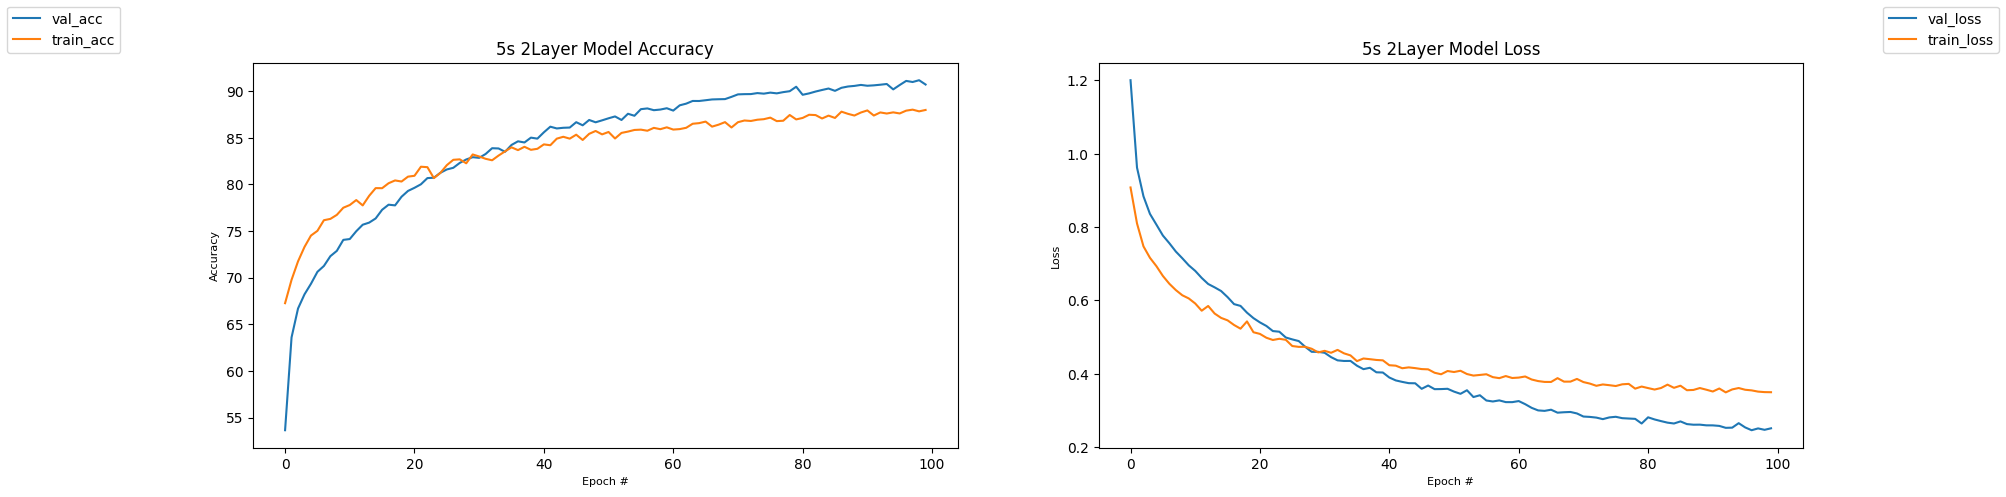

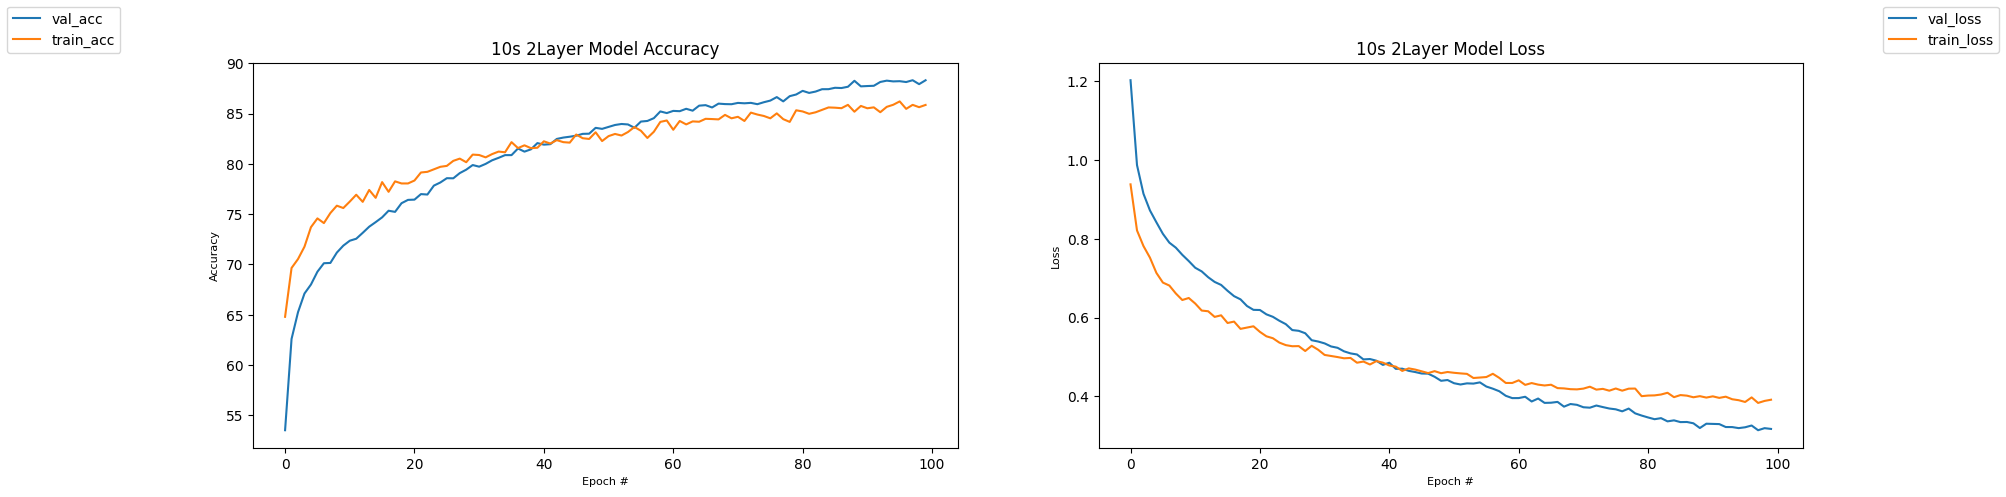

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
#loss_plot = [val_loss, train_loss]
#acc_plot = [val_acc, train_acc]
layers = [2]
def draw(acc_plot, loss_plot,dataset_name,layer):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    for line in acc_plot:
        ax1.plot(range(len(line)), line)
    ax1.set_xlabel("Epoch #", fontsize=8)
    ax1.set_ylabel("Accuracy", fontsize=8)
    ax1.set_title(f"{dataset_name} {str(layer)}Layer Model Accuracy")
    for line in loss_plot:
        ax2.plot(range(len(line)), line)
    ax2.set_xlabel("Epoch #", fontsize=8)
    ax2.set_ylabel("Loss", fontsize=8)
    ax2.set_title(f"{dataset_name} {str(layer)}Layer Model Loss")
    labels1 = ["val_acc", "train_acc"]
    labels2 = ["val_loss", "train_loss"]
    fig.legend(labels1, loc="upper left")
    fig.legend(labels2, loc="upper right")
for layer in layers:
    for loss_plot,acc_plot,name in zip(loss_result,acc_result,datasets.keys()):
        draw(acc_plot, loss_plot,name,layer)